# Sleep Quality - Multiple Linear Regression (MLR)

In [13]:
#import tools and data for training and preprocessing
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

sleepcycle_dataframe = pd.read_csv('sleep_cycle_productivity.csv')

sleepcycle_dataframe.head()

,Date,Person_ID,Age,Gender,Sleep Start Time,Sleep End Time,Total Sleep Hours,Sleep Quality,Exercise (mins/day),Caffeine Intake (mg),Screen Time Before Bed (mins),Work Hours (hrs/day),Productivity Score,Mood Score,Stress Level
0,2024-04-12,1860,32,Other,23.33,4.61,5.28,3,86,87,116,8.808920,8,3,6
1,2024-11-04,1769,41,Female,21.02,2.43,5.41,5,32,21,88,6.329833,10,3,7
2,2024-08-31,2528,20,Male,22.10,3.45,5.35,7,17,88,59,8.506306,10,9,10
3,2024-02-22,8041,37,Other,23.10,6.65,7.55,8,46,34,80,6.070240,8,4,2
4,2024-02-23,4843,46,Other,21.42,4.17,6.75,10,61,269,94,11.374994,8,7,9


In [14]:
#drop person_id, not an informative feature
sleepcycle_dataframe.drop(['Person_ID', 'Date', 'Gender'], axis=1, inplace=True)

sleepcycle_dataframe.info()
#note no null values to drop

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            5000 non-null   int64  
 1   Sleep Start Time               5000 non-null   float64
 2   Sleep End Time                 5000 non-null   float64
 3   Total Sleep Hours              5000 non-null   float64
 4   Sleep Quality                  5000 non-null   int64  
 5   Exercise (mins/day)            5000 non-null   int64  
 6   Caffeine Intake (mg)           5000 non-null   int64  
 7   Screen Time Before Bed (mins)  5000 non-null   int64  
 8   Work Hours (hrs/day)           5000 non-null   float64
 9   Productivity Score             5000 non-null   int64  
 10  Mood Score                     5000 non-null   int64  
 11  Stress Level                   5000 non-null   int64  
dtypes: float64(4), int64(8)
memory usage: 468.9 KB


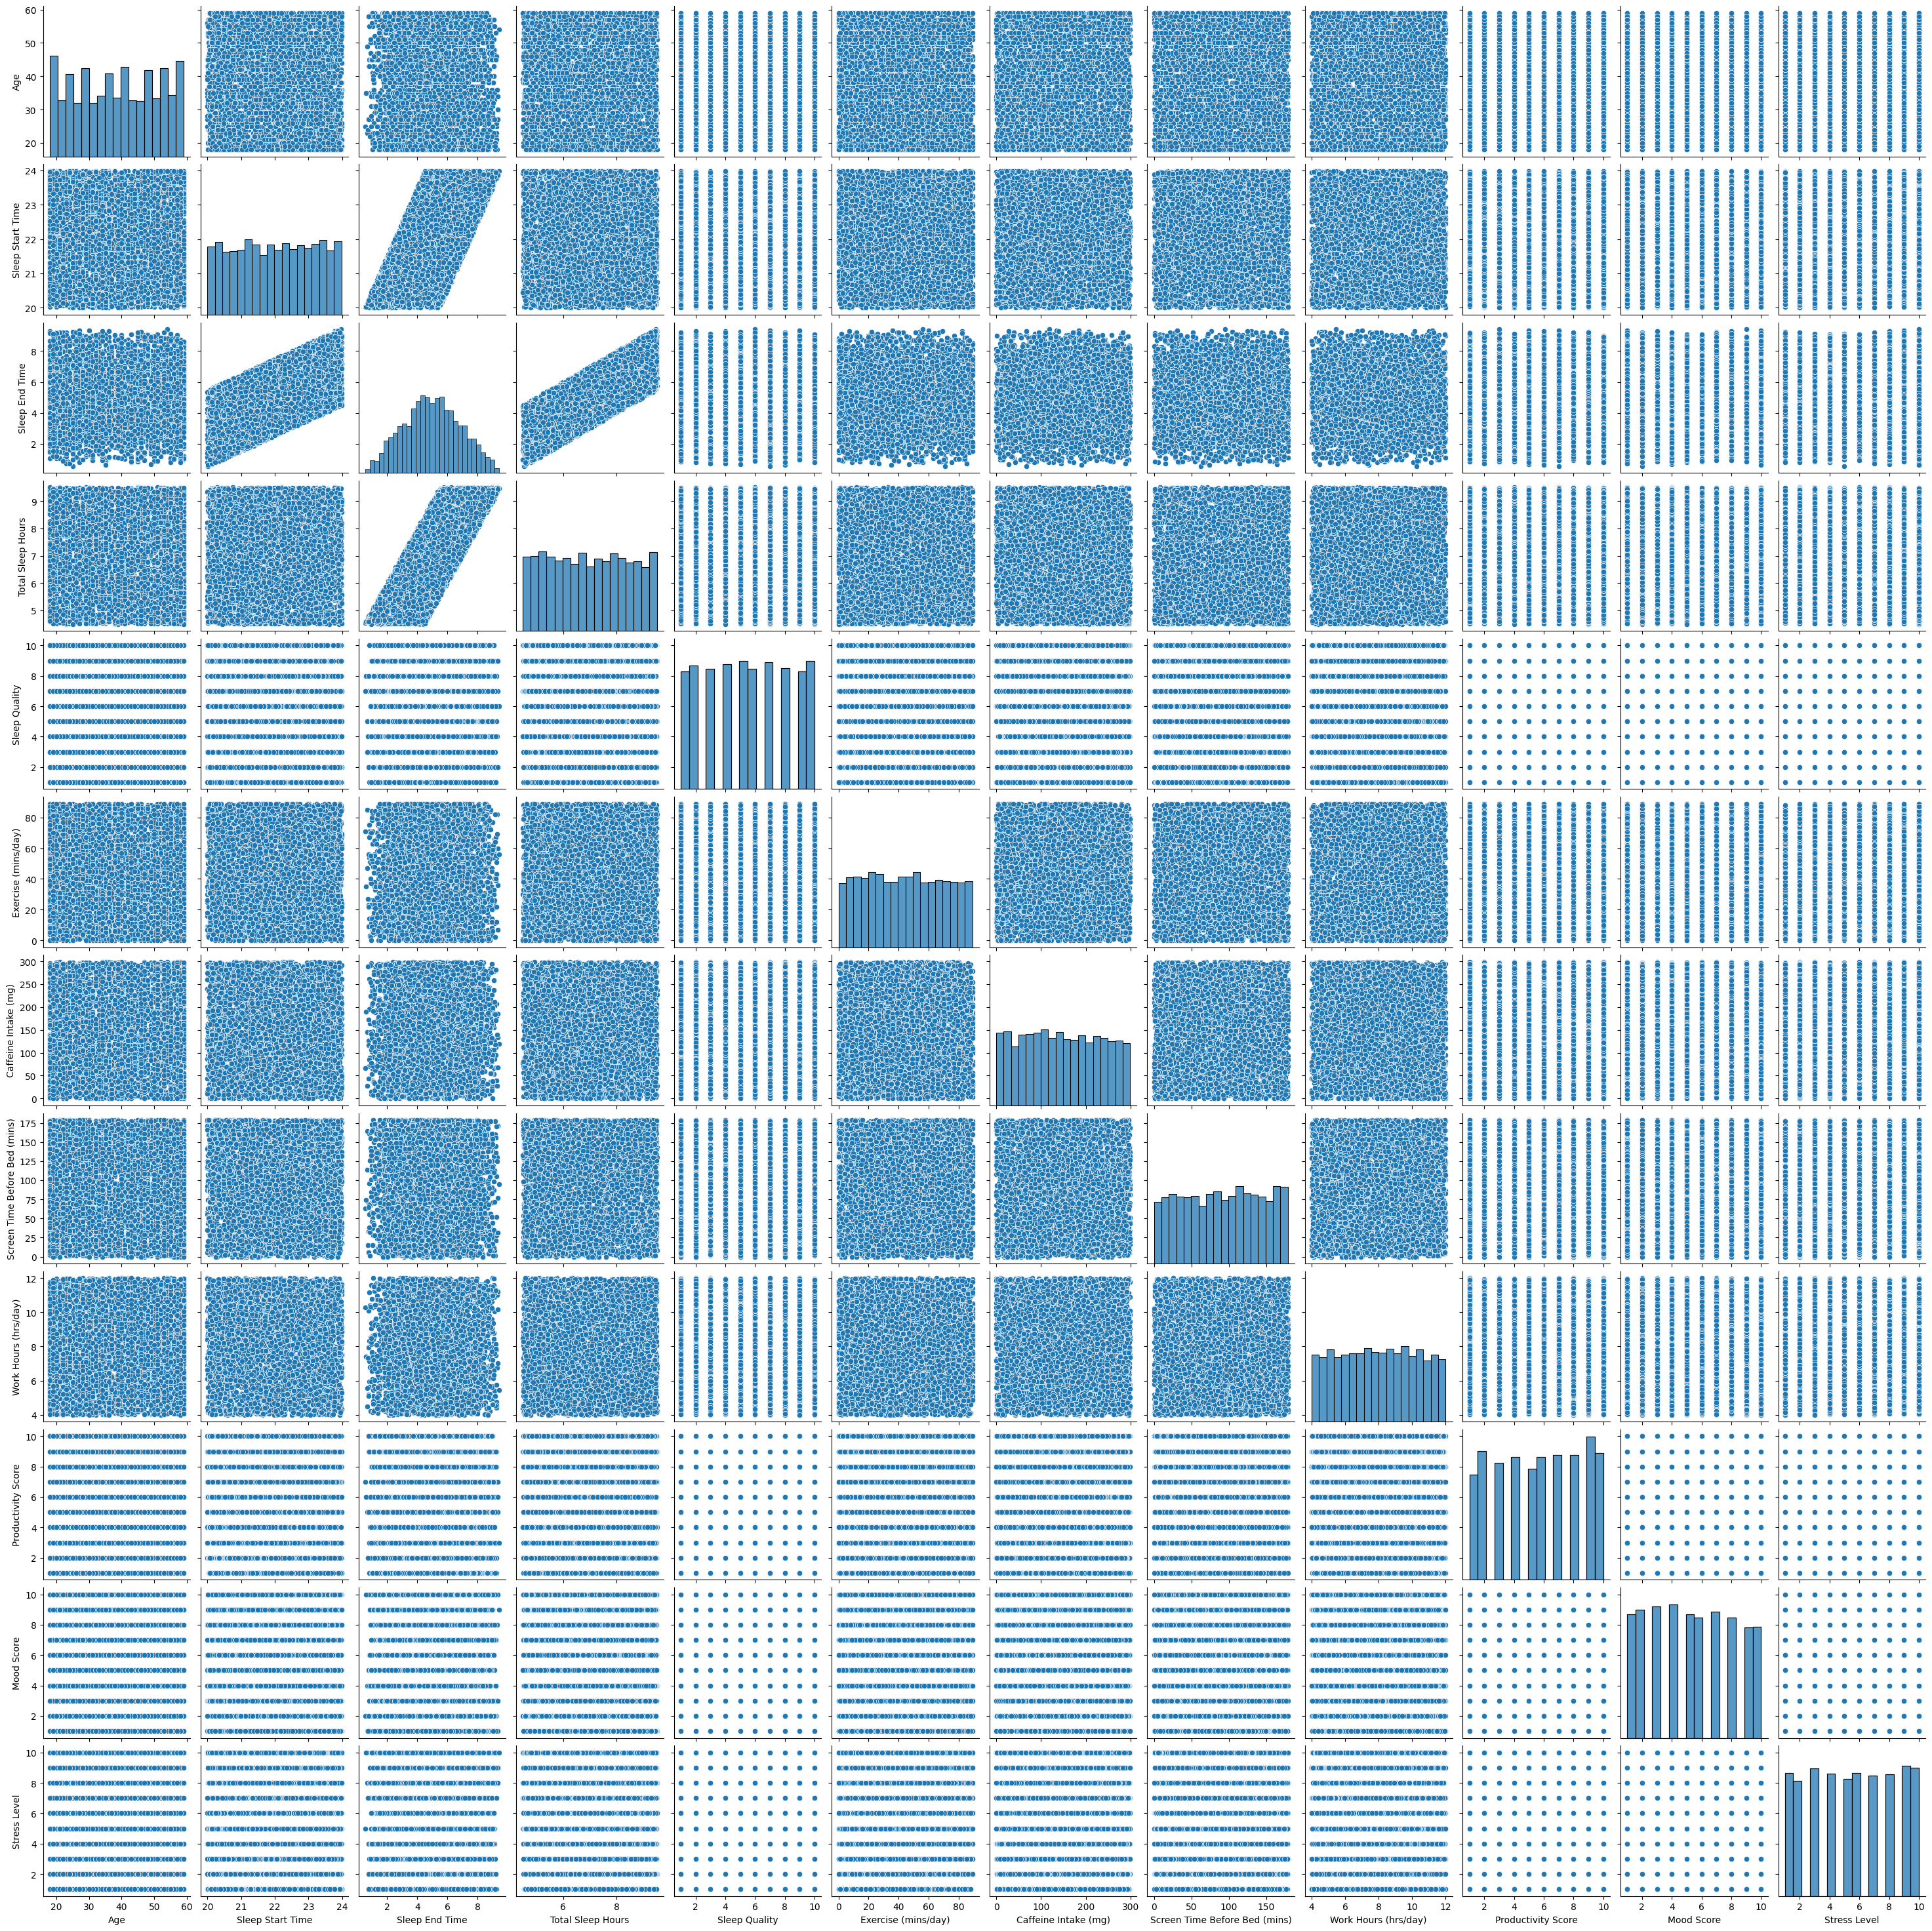

In [17]:
#plot the data to see if there are any trends
sns.pairplot(sleepcycle_dataframe)
plt.show()

In [15]:
#Split the data into training and testing sets
from sklearn.model_selection import train_test_split

X = sleepcycle_dataframe.drop('Sleep Quality', axis=1)
y = sleepcycle_dataframe['Sleep Quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [16]:
#fit model to training data
model = LinearRegression()
model.fit(X_train, y_train)

#predict on test data
y_pred = model.predict(X_test)

#evaluate model
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score

rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'RMSE: {rmse}')
print(f'R^2: {r2}')

RMSE: 2.8732394748941297
R^2: -0.00559947359873858
